# 02 — Quality control and filtering

Equivalent to `scripts/02_qc_filter.py`. Produces **Figure 1** of the report.

Droplet data contains three things that are not cells: empty droplets with ambient
RNA (few genes), dying cells (high mitochondrial fraction), and doublets (two cells
in one droplet, so too many genes). Each distorts clustering differently.

**Look at the distributions before you cut.** Thresholds copied from a tutorial are
not a justification you can defend at grading.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / 'scripts'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad

import config

sc.settings.verbosity = 3
sc.settings.figdir = config.FIG_DIR
sc.settings.set_figure_params(dpi=100, facecolor='white', frameon=False)
sc.logging.print_header()

Package,Version
numpy,2.4.6
pandas,2.3.3
matplotlib,3.11.2
scanpy,1.11.5
anndata,0.12.19
Component,Info
Python,"3.11.15 (main, Jun 23 2026, 15:19:43) [Clang 22.1.3 ]"
OS,Linux-6.18.33.1-microsoft-standard-WSL2-x86_64-with-glibc2.39
CPU,"8/8 logical CPU cores, x86_64"
GPU,No GPU found


In [2]:
adata = sc.read_h5ad(config.H5AD_RAW)
print(f'{adata.n_obs:,} cells x {adata.n_vars:,} genes')

88,991 cells x 17,481 genes


## Flag mitochondrial and ribosomal genes

*Drosophila* naming is **not** the human convention — there is no `MT-` prefix.
Mito genes are `mt:` (`mt:CoI`, `mt:ND1`, `mt:Cytb`); ribosomal proteins are
`RpS`/`RpL`. Getting this wrong gives every cell 0% mt, you filter nothing, and
nothing warns you.

In [3]:
adata.var['mt'] = adata.var_names.str.startswith('mt:')
adata.var['ribo'] = adata.var_names.str.startswith(('RpS', 'RpL', 'rps', 'rpl'))

print('mitochondrial genes:', int(adata.var['mt'].sum()))
print('ribosomal genes:   ', int(adata.var['ribo'].sum()))

assert adata.var['mt'].sum() > 0, (
    'No mt: genes found — your var_names are probably FlyBase IDs. Redo step 01.')

mitochondrial genes: 24
ribosomal genes:    92


In [4]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=['mt', 'ribo'], percent_top=None, log1p=False, inplace=True
)
adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].describe().round(2)

,n_genes_by_counts,total_counts,pct_counts_mt
count,88991.00,88991.00,88991.00
mean,1011.29,2585.12,0.42
std,589.53,3316.11,0.96
min,84.00,500.00,0.00
25%,572.00,920.00,0.10
50%,869.00,1666.00,0.23
75%,1271.00,2959.00,0.47
max,5850.00,142279.00,82.42


## Look before you cut

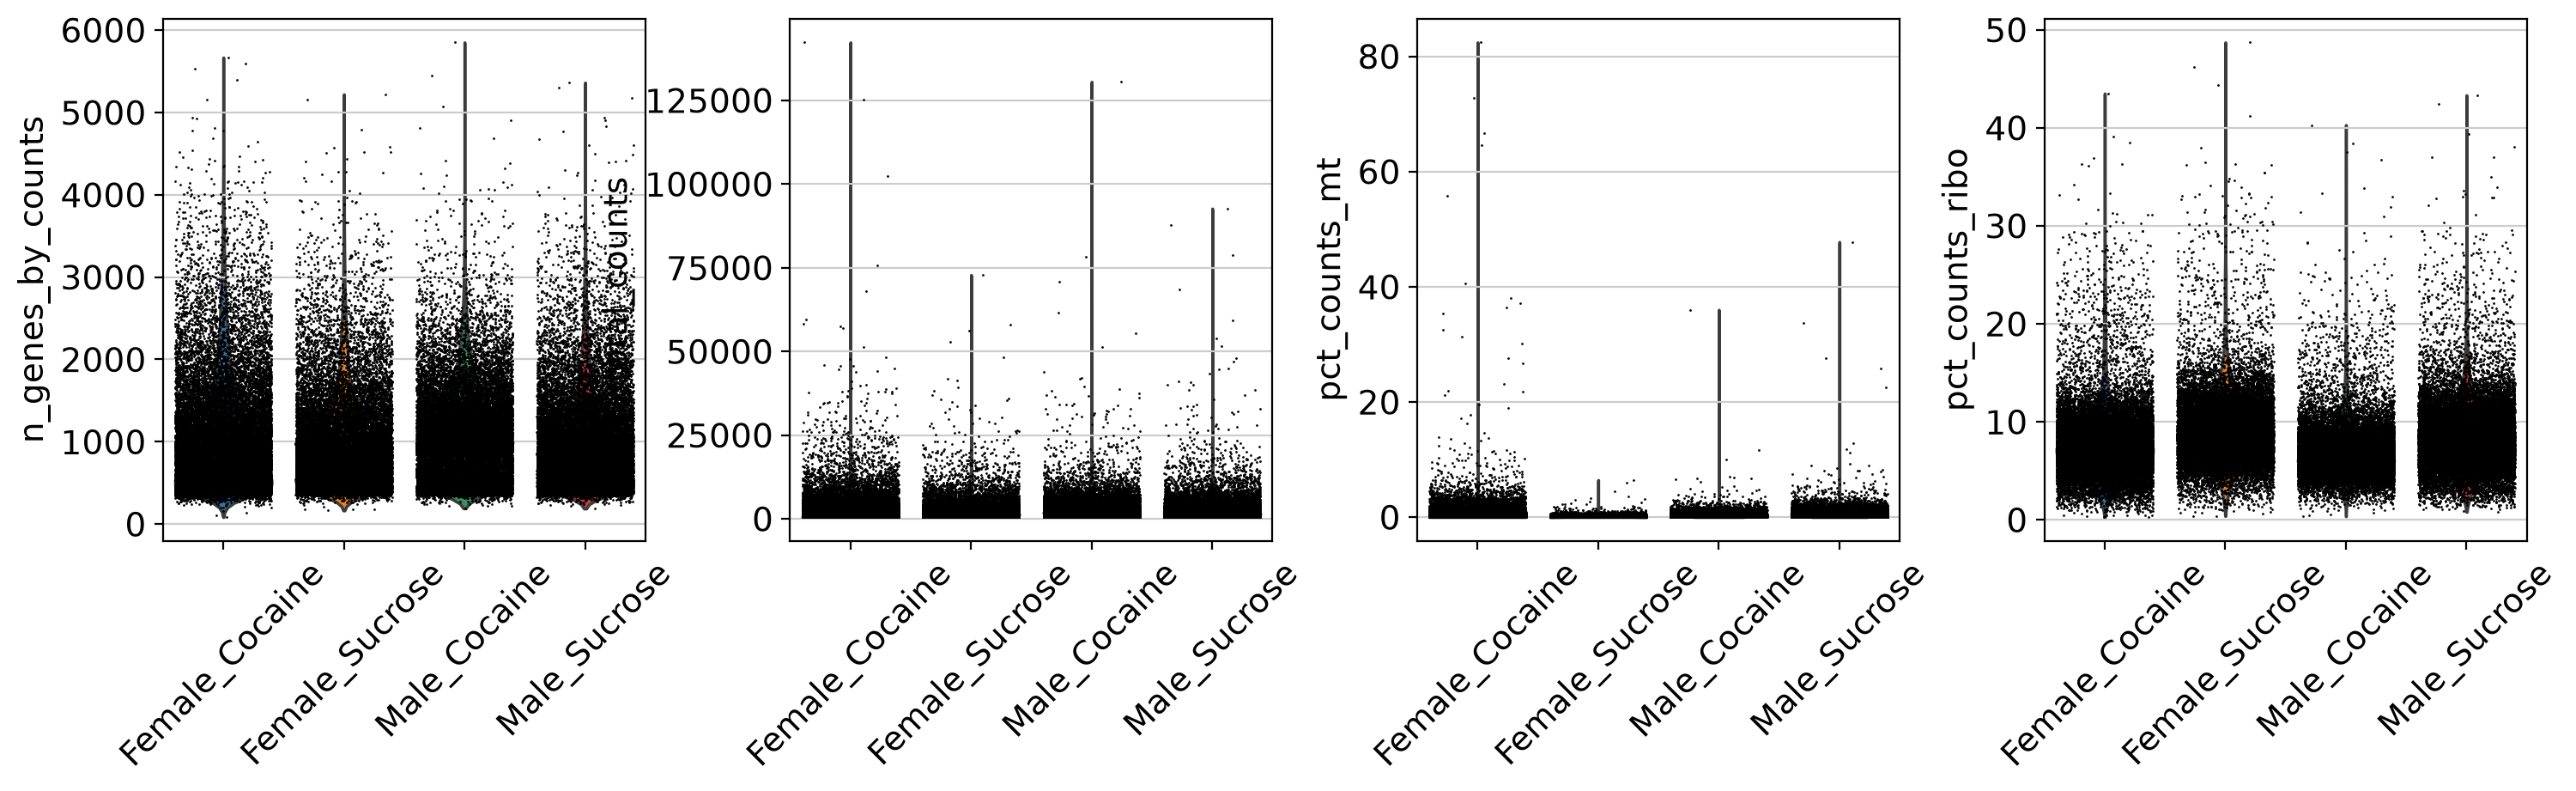

In [5]:
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo'],
    groupby='condition', jitter=0.4, multi_panel=True, rotation=45,
)

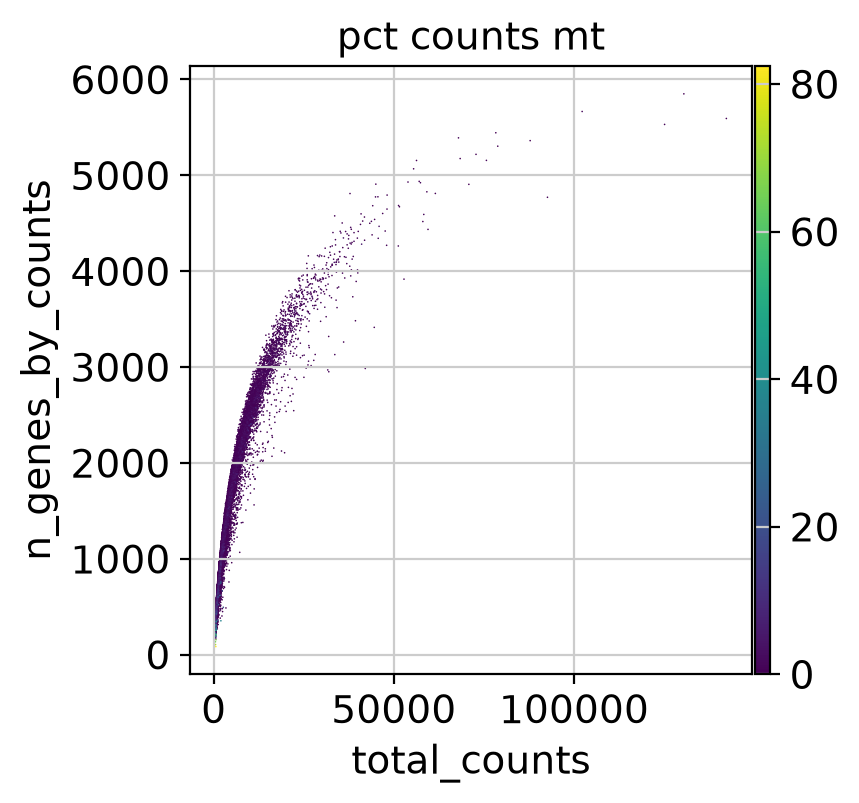

In [6]:
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', color='pct_counts_mt')

**Read these plots before continuing.**

- Does the mt% distribution peak below 10? If it peaks above, a 10% cut throws
  away real cells and you should raise it — and say so in Methods.
- Does one sample look different from the others? That is a batch effect to
  remember when you see the UMAP in step 03.
- Where does the cloud of low-gene droplets end? That is your real `min_genes`.

In [7]:
# Per-sample summary — goes into the Methods section
g = adata.obs.groupby('sample', observed=True)
before = pd.DataFrame({
    'n_cells': g.size(),
    'median_genes': g['n_genes_by_counts'].median(),
    'median_counts': g['total_counts'].median(),
    'median_pct_mt': g['pct_counts_mt'].median(),
}).round(2)
before

,n_cells,median_genes,median_counts,median_pct_mt
sample,,,,
Female_Cocaine_R1,13072,733.0,1304.0,0.16
Female_Cocaine_R2,9367,1080.0,2286.0,0.72
Female_Sucrose_R1,9072,771.5,1347.0,0.09
Female_Sucrose_R2,11693,807.0,1476.0,0.04
Male_Cocaine_R1,10437,680.0,1190.0,0.28
Male_Cocaine_R2,11124,1207.0,2868.0,0.25
Male_Sucrose_R1,13193,769.0,1378.0,0.32
Male_Sucrose_R2,11033,799.0,1440.0,0.47


## Filter

Thresholds come from `config.py`. Currently following the **paper's** Methods
(300–2500 genes, min 5 cells per gene) rather than the guide's looser numbers,
because RQ1 asks us to reproduce their 36 clusters.

In [8]:
n = adata.n_obs
for label, mask in [
    ('genes < 300',   adata.obs['n_genes_by_counts'] < config.MIN_GENES_PER_CELL),
    ('genes >= 2500', adata.obs['n_genes_by_counts'] >= config.MAX_GENES_PER_CELL),
    ('pct_mt >= 10',  adata.obs['pct_counts_mt'] >= config.MAX_PCT_MT),
]:
    print(f'{label:<16} {int(mask.sum()):>6,}  ({100*mask.sum()/n:.2f}%)')

print('\nFraction of each sample lost to min_genes=300:')
loss = (adata.obs.groupby('sample', observed=True)['n_genes_by_counts']
        .apply(lambda s: 100 * (s < config.MIN_GENES_PER_CELL).mean()).round(2))
print(loss.sort_values(ascending=False).to_string())

print('\nmt% by treatment:')
print(adata.obs.groupby('treatment', observed=True)['pct_counts_mt']
      .agg(['mean', 'median']).round(3).to_string())

genes < 300         267  (0.30%)
genes >= 2500     2,501  (2.81%)
pct_mt >= 10         62  (0.07%)

Fraction of each sample lost to min_genes=300:
sample
Female_Cocaine_R2    0.53
Male_Cocaine_R1      0.45
Female_Cocaine_R1    0.42
Male_Sucrose_R1      0.29
Male_Sucrose_R2      0.27
Female_Sucrose_R2    0.23
Female_Sucrose_R1    0.22
Male_Cocaine_R2      0.00

mt% by treatment:
            mean  median
treatment               
Cocaine    0.501   0.267
Sucrose    0.335   0.183


In [9]:
print('cells now:', adata.n_obs, 'of 88,991 originally')
print('gene range:', int(adata.obs['n_genes_by_counts'].min()),
      '-', int(adata.obs['n_genes_by_counts'].max()))

cells now: 88991 of 88,991 originally
gene range: 84 - 5850


In [10]:
print(adata.obs.groupby(['treatment','sex'], observed=True)['pct_counts_mt']
      .agg(['mean','median','count']).round(3).to_string())

                   mean  median  count
treatment sex                         
Cocaine   Female  0.646   0.278  22439
          Male    0.350   0.260  21561
Sucrose   Female  0.103   0.059  20765
          Male    0.535   0.373  24226


In [11]:
print(f'Retained {adata.n_obs:,} / 88,991 ({100*adata.n_obs/88991:.2f}%)')
print(f'Paper: 86,224 — difference {86224 - adata.n_obs:+,} cells')
print(f'\nGenes: {adata.n_vars:,}')
print('\nCells per sample after QC:')
print(adata.obs['sample'].value_counts().sort_index().to_string())
print('\nDesign:')
import pandas as pd
print(pd.crosstab(adata.obs['sex'], adata.obs['treatment']).to_string())

Retained 88,991 / 88,991 (100.00%)
Paper: 86,224 — difference -2,767 cells

Genes: 17,481

Cells per sample after QC:
sample
Female_Cocaine_R1    13072
Female_Cocaine_R2     9367
Female_Sucrose_R1     9072
Female_Sucrose_R2    11693
Male_Cocaine_R1      10437
Male_Cocaine_R2      11124
Male_Sucrose_R1      13193
Male_Sucrose_R2      11033

Design:
treatment  Cocaine  Sucrose
sex                        
Female       22439    20765
Male         21561    24226


In [12]:
missing = [g for gs in config.CANONICAL_MARKERS.values()
           for g in gs if g not in adata.var_names]
print('markers lost to min_cells filter:', missing if missing else 'none')

for g in ['CG5842', 'na', 'mt:lrRNA', 'ninaE', 'lncRNA:roX1', 'Yp1']:
    print(f'  {g:<14} {"present" if g in adata.var_names else "LOST"}')

markers lost to min_cells filter: none
  CG5842         present
  na             present
  mt:lrRNA       present
  ninaE          present
  lncRNA:roX1    present
  Yp1            present


In [13]:
feat = pd.read_csv(
    config.DATA_DIR / 'Female_Cocaine_1' / 'features.tsv.gz',
    sep='\t', header=None, names=['gene_id', 'symbol', 'type'],
    keep_default_na=False,
)

for target in ['VGlut', 'rut', 'dnc', 'Trh', 'Tret1-1', 'CG5842']:
    hits = feat[feat['symbol'].str.lower() == target.lower()]
    if len(hits) == 0:
        # try substring, to catch naming variants
        hits = feat[feat['symbol'].str.contains(target, case=False, regex=False)]
        print(f'{target:<10} exact: NOT FOUND | similar: {hits["symbol"].tolist()[:6]}')
    else:
        print(f'{target:<10} in annotation as: {hits["symbol"].tolist()}')

VGlut      exact: NOT FOUND | similar: ['VGlut1', 'VGlut2']
rut        exact: NOT FOUND | similar: []
dnc        exact: NOT FOUND | similar: []
Trh        in annotation as: ['trh']
Tret1-1    exact: NOT FOUND | similar: []
CG5842     exact: NOT FOUND | similar: []


In [14]:
expected = {
    'CG9887':  'VGlut (vesicular glutamate transporter)',
    'CG9533':  'rut / rutabaga (adenylyl cyclase)',
    'CG32498': 'dnc / dunce (phosphodiesterase)',
    'CG9122':  'Trh / tryptophan hydroxylase — SEROTONERGIC',
    'CG42865': 'trh / trachealess — NOT a serotonin gene',
    'CG30035': 'Tret1-1 (trehalose transporter)',
}

for cg, desc in expected.items():
    hits = feat[feat['gene_id'].str.contains(cg, case=False, regex=False)]
    if len(hits):
        for _, r in hits.iterrows():
            print(f'{cg:<9} -> symbol {r["symbol"]:<16} | {desc}')
    else:
        print(f'{cg:<9} -> NOT IN REFERENCE     | {desc}')

print('\nWhat VGlut1/VGlut2 actually are:')
print(feat[feat['symbol'].isin(['VGlut1', 'VGlut2'])].to_string(index=False))

print('\nWhat the trh hit actually is:')
print(feat[feat['symbol'].str.lower() == 'trh'].to_string(index=False))

CG9887    -> symbol VGlut1           | VGlut (vesicular glutamate transporter)
CG9533    -> symbol Adcy1            | rut / rutabaga (adenylyl cyclase)
CG32498   -> symbol Pde4             | dnc / dunce (phosphodiesterase)
CG9122    -> symbol Trhn             | Trh / tryptophan hydroxylase — SEROTONERGIC
CG42865   -> symbol trh              | trh / trachealess — NOT a serotonin gene
CG30035   -> symbol Tret1            | Tret1-1 (trehalose transporter)

What VGlut1/VGlut2 actually are:
    gene_id symbol            type
Dmel_CG9887 VGlut1 Gene Expression
Dmel_CG4288 VGlut2 Gene Expression

What the trh hit actually is:
     gene_id symbol            type
Dmel_CG42865    trh Gene Expression


In [15]:
print('min_genes    :', config.MIN_GENES_PER_CELL)
print('max_genes    :', config.MAX_GENES_PER_CELL)
print('min_cells    :', config.MIN_CELLS_PER_GENE)
print('max_pct_mt   :', config.MAX_PCT_MT)

min_genes    : 300
max_genes    : 2500
min_cells    : 5
max_pct_mt   : 10.0


In [16]:
n0 = adata.n_obs

sc.pp.filter_cells(adata, min_genes=config.MIN_GENES_PER_CELL)
print(f'after min_genes: {adata.n_obs:,}')

if config.MAX_GENES_PER_CELL is not None:
    adata = adata[adata.obs['n_genes_by_counts'] < config.MAX_GENES_PER_CELL].copy()
    print(f'after max_genes (doublets): {adata.n_obs:,}')

adata = adata[adata.obs['pct_counts_mt'] < config.MAX_PCT_MT].copy()
print(f'after pct_mt: {adata.n_obs:,}')

sc.pp.filter_genes(adata, min_cells=config.MIN_CELLS_PER_GENE)
print(f'genes retained: {adata.n_vars:,}')

print(f'\nRetained {adata.n_obs:,}/{n0:,} cells ({100*adata.n_obs/n0:.1f}%)')
print('Paper analysed 86,224 cells.')

filtered out 267 cells that have less than 300 genes expressed


after min_genes: 88,724


after max_genes (doublets): 86,223


after pct_mt: 86,177


filtered out 5292 genes that are detected in less than 5 cells


genes retained: 12,189

Retained 86,177/88,991 cells (96.8%)
Paper analysed 86,224 cells.


## Confirm the design is still balanced

If one arm lost most of its cells, the DE comparison is compromised and you must
say so in the report rather than present the design as intact.

In [17]:
adata.obs['condition'].value_counts().sort_index()

condition
Female_Cocaine    21285
Female_Sucrose    20240
Male_Cocaine      21071
Male_Sucrose      23581
Name: count, dtype: int64

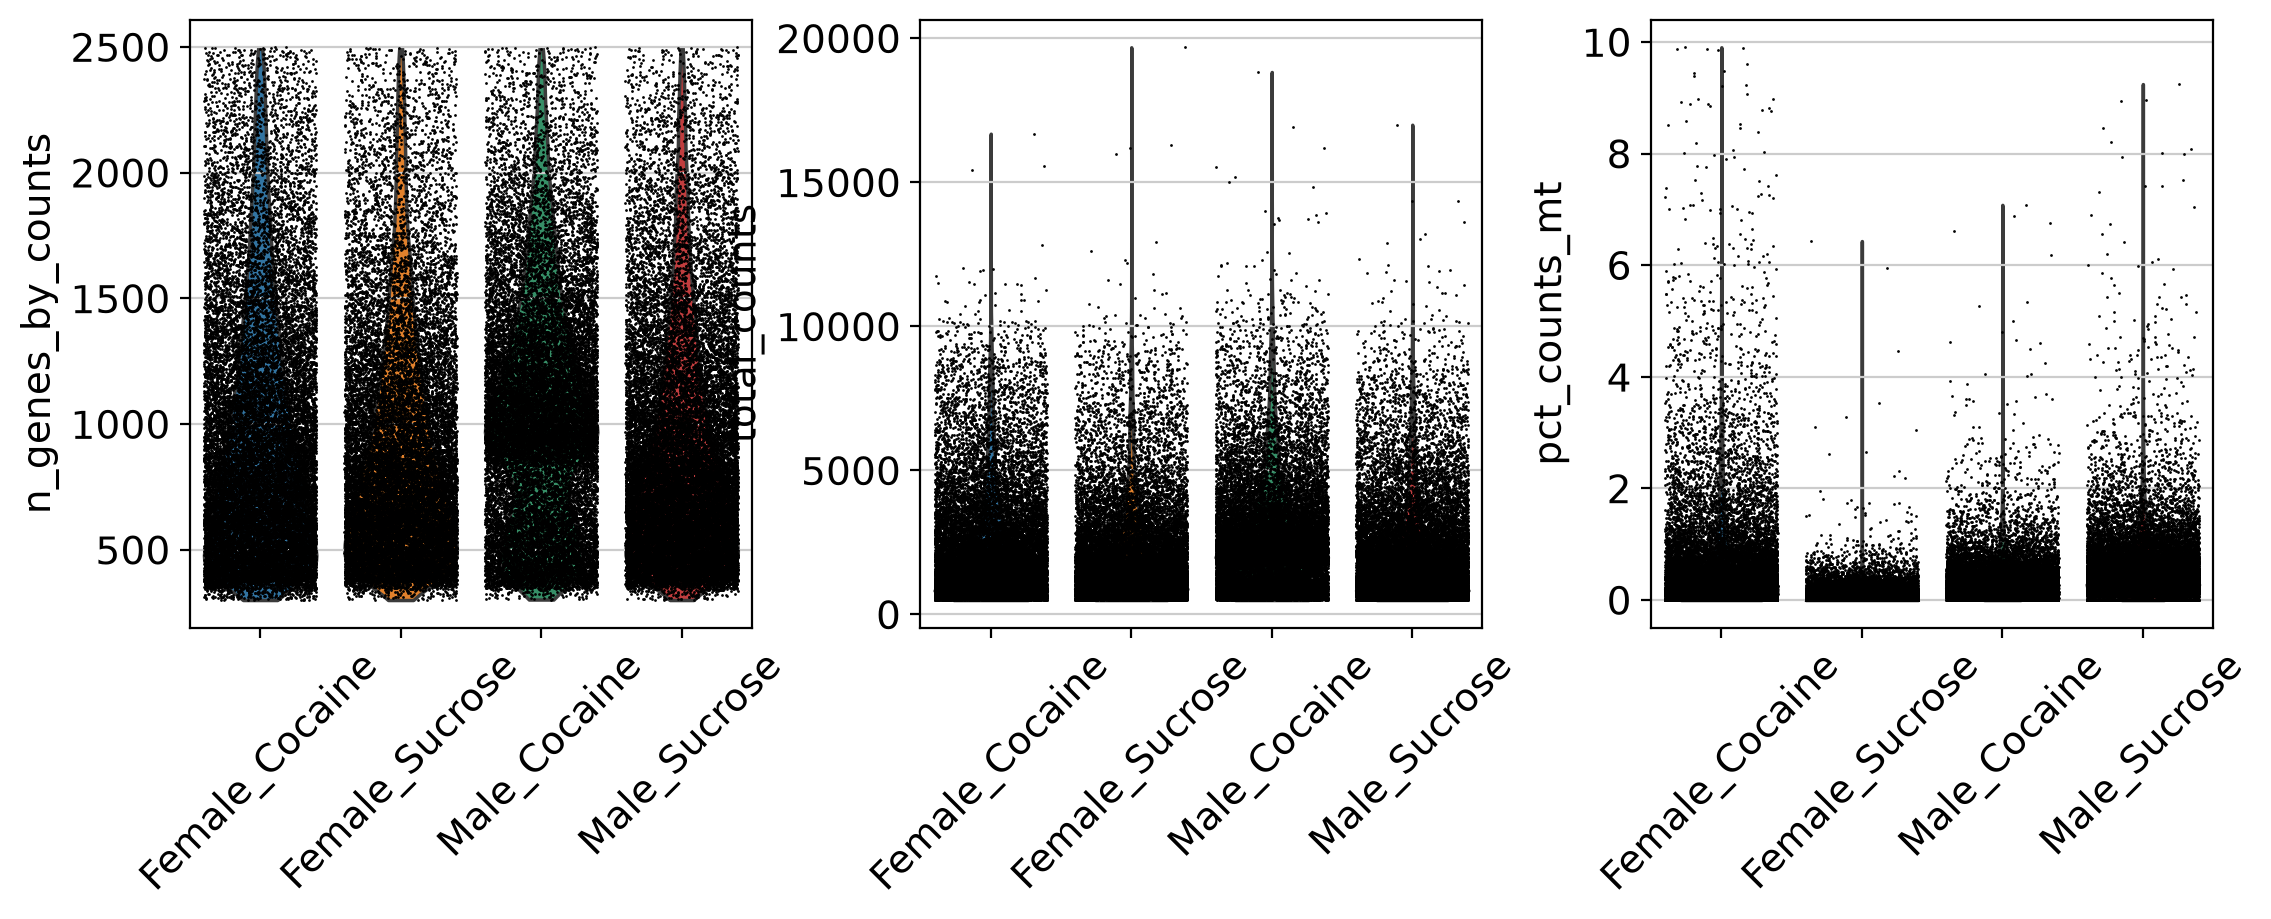

In [18]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             groupby='condition', jitter=0.4, multi_panel=True, rotation=45)

In [19]:
adata.write(config.H5AD_QC)
print('Wrote', config.H5AD_QC)

Wrote /mnt/d/project2_drosophila_brain/results/checkpoints/02_qc_filtered.h5ad
